Projet segmentez des clients d'un site e-commerce

notebook exploration des données

Created by: Thomas Durand-Texte, 2023

**Table of contents**<a id='toc0_'></a>    
- 1. [Import des packages et données](#toc1_)    
  - 1.1. [import des packages](#toc1_1_)    
  - 1.2. [Paramètres graphiques et fonctions utiles](#toc1_2_)    
  - 1.3. [Chargement des données](#toc1_3_)    
  - 1.4. [Fusion des dataset d'intérêt](#toc1_4_)    
- 2. [Analyse des données](#toc2_)    
  - 2.1. [Données brutes](#toc2_1_)    
  - 2.2. [Analyse par quantiles](#toc2_2_)    
  - 2.3. [Analyse de variables supplémentaires](#toc2_3_)    
    - 2.3.1. [Review score](#toc2_3_1_)    
    - 2.3.2. [Retard de livraison](#toc2_3_2_)    
    - 2.3.3. [Type de paiement](#toc2_3_3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Import des packages et données](#toc0_)
## 1.1. <a id='toc1_1_'></a>[import des packages](#toc0_)

In [2]:
import os

import pandas as pd
import numpy as np
# import dask as dd
pd.set_option("display.max_columns", 200)
import datetime as dt
import scipy.stats as st

from statsmodels.multivariate.manova import MANOVA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda

import time

import pickle

from sklearn import model_selection, metrics, preprocessing
from sklearn import cluster

import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

import plotly.express as px

cm = 1./2.54
path_print = 'Figures/explore/'

ModuleNotFoundError: No module named 'yellowbrick'

## 1.2. <a id='toc1_2_'></a>[Paramètres graphiques et fonctions utiles](#toc0_)

In [ ]:
import subprocess

white_font = True
def set_theme( white_font=True ):
    """Réglages graphiques

    Args:
        white_font (bool, optional): set if font a set to white (True) or black (False). Defaults to True.
    """
    if white_font: wht, grey, blck = '0.84' , '0.5', 'k'
    else: wht, grey, blck = 'k', '0.5', '0.84'
    rc = { 'figure.facecolor':(0.118,)*3,
            'axes.labelcolor':wht,
            'axes.edgecolor':wht,
            'axes.facecolor':(0,0,0,0),
            'text.color':'white',
            'text.usetex':False,
            'text.latex.preamble':r'\usepackage[cm]{sfmath} \usepackage{amsmath}' ,
            'font.family': 'sans-serif' ,
            'font.sans-serif': 'DejaVu Sans' ,
            'xtick.color':wht,
            'ytick.color':wht,
            "axes.grid" : True,
            "grid.color": (0.7,)*3,
            "grid.linewidth": 0.4,
            "grid.linestyle": (10,5),
            'legend.edgecolor':'0.2',
            'legend.facecolor':(0.2,0.2,0.2,0.6),
            # 'legend.framealpha':'0.6',
            'pdf.fonttype':42,
            'savefig.format':'pdf',
            'savefig.transparent':True,
            'figure.dpi':150, # for better agreemet figsize vs real size
        }

    sns.set_theme( 'notebook' , rc=rc )
    return


def make_folder( path_folder:str ):
    """Create a folder given the path. Test is performed first to check if folder already exists or not.

    Args:
        path_folder (str): path to the folder
    """
    path_folder = path_folder.__str__()
    try:
        if os.path.isdir( path_folder ) : return
        os.makedirs(path_folder)
    except OSError:
        pass
    return


def concat_folders(*args, **kwargs)->str:
    """Concatenate strings to form a path to a folder

    exemple concat_filders('/abc', 'ABC') -> '/abc/ABC/'

    Returns:
        str: concatenated string corresponding to a path to a folder
    """
    sPath = ''
    for arg in args:
        if arg == '..': sPath = sPath[:sPath[:-1].rfind(os.sep)+1]
        else: sPath += arg
        if sPath[-1] != os.sep: sPath += os.sep
    return sPath


class Path(object):
    """ Path( s_in='', s_lim=None)
        create a path to the string s_in (default is current path)
        and stops after s_lim """
    n_Path = 0
    def __init__(self, s_in='', s_lim=None):
        """Initialisation of class Path

        Args:
            s_in (str, optional): string corresponding to a folder path. Defaults to '' (current working directory).
            s_lim (_type_, optional): chain to limit the path. Defaults to None. Example s_in = '/folder_1/folder_2/folder_3', s_lim = '2', leads to '/folder_1/folder_2/'
        """
        if s_in == '': s_in = os.getcwd()
        if not s_lim is None:
            if s_lim in s_in:
                s_in = s_in[ :s_in.index( s_lim ) + len(s_lim) ]
        self.sPath = concat_folders(s_in)
        self.N = Path.n_Path
        Path.n_Path += 1
        return

    def __add__(self, other):
        """ Path + str : return str """
        if isinstance(other, str): return self.sPath + other

    def __truediv__(self, other):
        """ Path / str : return path concatenated"""
        if isinstance(other, str): return Path(concat_folders(self.sPath, other))

    def __invert__(self):
        """ ~Path : return str of the path """
        return self.sPath

    def __str__(self):
        """ __str__ return str of the path """
        return self.sPath
    # __str__ #

    def makedir( self ):
        """ Create a folder from current path if it does not exists """
        return make_folder( self )


def gs_opt( filename:str ):
    """otpimisation of a pdf file with gosthscript

    Args:
        filename (str): string corresponding to the pdf file to optimise
    """
    filenameTmp = filename.replace('.pdf', '') + '_tmp.pdf'
    gs = ['gs',
            '-sDEVICE=pdfwrite',
            '-dEmbedAllFonts=true',
            '-dSubsetFonts=true',             # Create font subsets (default)
            '-dPDFSETTINGS=/prepress',        # Image resolution
            '-dDetectDuplicateImages=true',   # Embeds images used multiple times only once
            '-dCompressFonts=true',           # Compress fonts in the output (default)
            '-dNOPAUSE',                      # No pause after each image
            '-dQUIET',                        # Suppress output
            '-dBATCH',                        # Automatically exit
            '-sOutputFile='+filenameTmp,      # Save to temporary output
            filename]                         # Input file

    subprocess.run(gs)                                      # Create temporary file
    subprocess.run( 'rm -f ' + filename, shell=True)            # Delete input file
    subprocess.run( 'mv -f ' + filenameTmp + " " + filename, shell=True) # Rename temporary to input file


def savefig( fig, savename:str, **kwargs ):
    """Saves a figure with kwargs (fig.savefig( savename, **kwargs) ).
       A check is done first to determine if a folder has to be created according to savename.
       Finally, if the file is saved as .pdf, gosthscript optimisation is performed.

    Args:
        fig : matplotlib figure
        savename (str): string of the name of the output pdf file
    """


    if os.sep in savename: make_folder( savename[:savename.rindex(os.sep)] )
    fig.savefig( savename, **kwargs )
    savename += '.pdf'
    if os.path.isfile( savename ): gs_opt( savename )
    return


def image_size_from_shape( shape: tuple, width: float = None, height: float = None, ymargin=0. ):
    """Compute tuple (width, height) from shape tuple of an image an width or height

    Args:
        shape (tuple): shape of the image (n_rows, n_cols)
        width (float, optional): desired width. Defaults to None.
        height (float, optional): desired height. Defaults to None.
        ymargin (_type_, optional): margin added to the output height. Defaults to 0..

    Returns:
        tuple: (width, height)
    """
    if not width is None:
        return width, width*shape[0]/shape[1] + ymargin
    if not heihgt is None:
        return height*shape[1]/shape[0]+xmargin, height
    else:
        print('\n!!! image_size_from_shape: nor width nor heigth was provided !!!\n')
        return shape


set_theme()
del set_theme

## 1.3. <a id='toc1_3_'></a>[Chargement des données](#toc0_)

Affichage de l'arborescence

In [3]:
def print_listdir(path=None, level=0, exclude=[]):
    """Affiche l'arborescence des dossiers et fichiers

    Args:
        path (_type_, optional): chemin du dossier à explorer. Defaults to None.
        level (int, optional): niveau d'indentation. Defaults to 0.
        exclude (list, optional): dossiers = exclure. Defaults to [].
    """
    suffix = ''
    if level > 0:
        suffix = ' |-'* level
    vals = os.listdir( path )
    vals.sort()
    if path is None:
        path = ''
    for val in vals:
        if val in exclude: continue
        print( suffix, val)
        if os.path.isdir( path + val):
            print_listdir( path + val + '/', level+1 )
    return

print_listdir( exclude=['.venv', '.venv2', 'ressources', 'devel', 'Figures', 'diaporama'] )

 data
 |- cleaned
 |- |- iteration_tsne_RFM.pickle
 |- |- iteration_tsne_RFM_delay.pickle
 |- |- iteration_tsne_RFM_review_score.pickle
 |- |- iteration_tsne_RFM_type_payment.pickle
 |- data_diagram.png
 |- data_diagram_resized.png
 |- source
 |- |- olist_customers_dataset.csv
 |- |- olist_customers_dataset.csv.zip
 |- |- olist_geolocation_dataset.csv
 |- |- olist_geolocation_dataset.csv.zip
 |- |- olist_order_items_dataset.csv
 |- |- olist_order_items_dataset.csv.zip
 |- |- olist_order_payments_dataset.csv
 |- |- olist_order_payments_dataset.csv.zip
 |- |- olist_order_reviews_dataset.csv
 |- |- olist_order_reviews_dataset.csv.zip
 |- |- olist_orders_dataset.csv
 |- |- olist_orders_dataset.csv.zip
 |- |- olist_products_dataset.csv
 |- |- olist_products_dataset.csv.zip
 |- |- olist_sellers_dataset.csv
 |- |- product_category_name_translation.csv
 exploration.ipynb
 install_packages_venv.sh
 install_packages_venv2.sh
 notebook_essais.ipynb
 notebook_simulation_RFM.ipynb


Chargement

In [45]:
path = 'data/source/'

filenames = ['customers', 'orders', 'order_items', 'order_payments', 'order_reviews', 'products', 'sellers']
dfs = {filename: pd.read_csv(path + f'olist_{filename}_dataset' + '.csv') for filename in filenames}
filename = 'product_category_name_translation'
dfs[filename] = pd.read_csv(path + filename + '.csv')

path_save = 'data/cleaned/'

Chaque jeu de données est relié à un ou plusieurs autres jeux à partir d'une variable. En regardant l'image ci-dessous, le dataset "`orders`" est lié aux dataset "`order_payments`", "`oder_reviews`" et "`order_items`" par la variable "`order_id`", ainsi qu'au dataset "`customer`" (order_customer dans l'image) par la variable "`customer_id`".

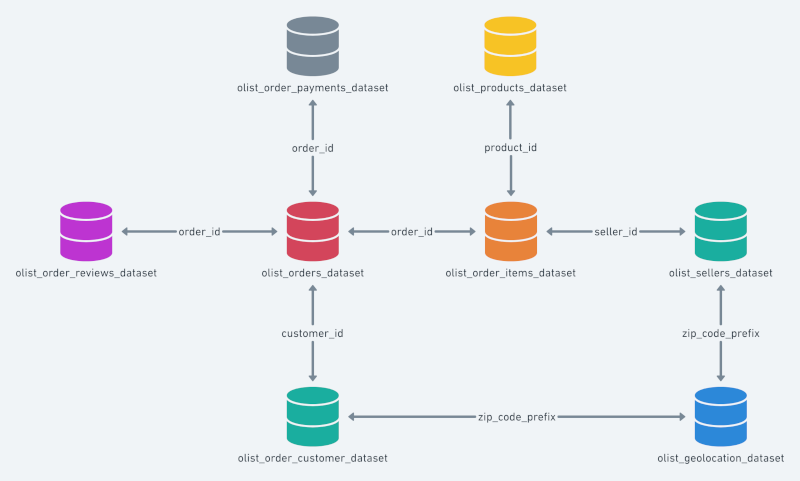

In [46]:
for filename, df_tmp in dfs.items():
    display( df_tmp.sample(5).style.set_caption(filename) )
    print('\n\n')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
6248,dc75a87fffc1d1b008e2e1606edb0a19,87603dde65ee7120467ddda1a883bb24,74720,goiania,GO
77690,4ff4005a59f62227c1bca8e0d84f08f7,20501a5c0c49dd3e41e22d1f59f5b076,21041,rio de janeiro,RJ
5869,f9b63cae30a80c6d141f817564ca31ff,ceac2416c11b2dccc354ad4981f38ab2,4517,sao paulo,SP
5326,42c0b09d094220a110c0e0e941f76f06,527f7f3237fb1397c459701bc765b6f0,55500,escada,PE
12811,65d79ebd74ab7244b7c75799809ce6c6,bc9bb036f1529c6cac46245640498a98,89221,joinville,SC


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
67071,fb48c152551174a69444383a2a7dce73,da0198a12413775e44e59d0a0277133a,delivered,2018-05-10 07:59:50,2018-05-10 08:18:24,2018-05-11 08:17:00,2018-05-17 12:44:20,2018-06-04 00:00:00
92473,4d288f2f1f3b59a97c364a2bf728b912,6e875338f7a2933dcabb08b9404c3f72,delivered,2018-06-14 14:54:38,2018-06-14 15:20:49,2018-06-15 13:35:00,2018-06-18 12:17:37,2018-07-04 00:00:00
79335,223f47f5cccb611b2c3058c1bbba5a4b,c03f13a216dc4a2cf98a0109ca7aed80,delivered,2018-01-13 16:07:57,2018-01-13 16:15:34,2018-01-15 19:22:19,2018-01-29 17:29:32,2018-02-15 00:00:00
97159,eb2dc067ee1a4eac77e2d045f01cf7f0,78101fe486eab484a8d65d53b69f4b09,unavailable,2017-12-04 23:16:03,2017-12-05 10:30:41,nan,nan,2017-12-20 00:00:00
33362,db2bd06455f798cb0da8e649c3aa06f9,f8d3de89915324398f75b2f37ee7406f,delivered,2017-10-23 10:40:44,2017-10-25 02:28:35,2017-10-26 19:46:46,2017-11-08 21:06:49,2017-11-14 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
28506,40e240e00303ab3cee64520a5ccf3388,1,985c412b0ac92ed9d8a76bbeab6d44eb,1554a68530182680ad5c8b042c3ab563,2017-08-08 21:38:33,68.900000,17.730000
85085,c14e0917a7e78c27cc4af1053e2d77f8,1,c5841303f830680eb1cdda8be0ff35bf,b561927807645834b59ef0d16ba55a24,2018-01-31 10:58:19,38.000000,14.100000
103707,eb829be78140383da9cba1b8fc2c6c6f,1,5a6e53c3b4e8684b13388d6aa4afdf12,7299e27ed73d2ad986de7f7c77d919fa,2017-03-20 11:24:10,14.990000,10.960000
48814,6eec08eba397611760a7ccd3cd4aa98b,1,bee760e5d1648771c6923cc199b11ba8,855668e0971d4dfd7bef1b6a4133b41b,2017-09-13 10:34:36,25.000000,7.780000
112155,fed00c385d43753c877738a19d1ea88e,1,a2ee607f03a8f581d1625b68fbaa6166,1835b56ce799e6a4dc4eddc053f04066,2017-12-21 02:17:39,27.990000,11.850000


,order_id,payment_sequential,payment_type,payment_installments,payment_value
12249,56d0a27ec26d1644336aff1ec939c089,1,credit_card,1,121.560000
75528,3e30e6710e775ebfeecbd90fad476396,1,boleto,1,70.720000
68271,751bac184f225318704b7bbf878bcc52,1,credit_card,3,454.000000
55413,11735753f4576ee70b2cc1e246a49fb4,1,credit_card,1,165.180000
50781,4e55b06f6fb2f612f4bf4723563fd326,1,credit_card,1,24.020000


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25679,d15fef3c853d25170dad47b38e1479cd,633dd5a92f78d119e8d78b055c418fcd,5,nan,Me surpreendeu a qualidade.,2018-01-03 00:00:00,2018-01-04 10:38:13
94791,b926a05198625076fe8af828ee4b9be0,e8b6b776c3fea4d15b0334a28cdf79d1,5,nan,nan,2018-08-17 00:00:00,2018-08-17 19:58:04
56320,0857872f03ef22e3dbe8391c4dd331f6,4bb9c2002502ca416276dc1ff5efb1b3,1,Não foi entregue,nan,2018-05-18 00:00:00,2018-05-21 18:15:06
10932,21dfbee68a7149226a3bc04699ce8b07,e0162395d367ee9b019d565333294e14,5,ATENDE ÀS EXPECTATIVAS,Produto em perfeito estado.,2018-07-04 00:00:00,2018-07-08 17:29:21
84116,cf9f6dc671f2b07a1ca76ea3e291b832,d0387cb335169ba746948d0acddc51ae,1,nan,nan,2017-10-31 00:00:00,2017-11-03 11:48:35


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
28542,982399060e81855f21f31f1102cbc1aa,automotivo,55.000000,322.000000,2.000000,400.000000,20.000000,20.000000,20.000000
27161,d58020f0dc3b18e41728f846f5072a6c,telefonia,58.000000,678.000000,3.000000,150.000000,17.000000,8.000000,14.000000
25398,4efd35570dbaaa27e216bd8bf3ed4cf3,moveis_escritorio,26.000000,1148.000000,1.000000,15925.000000,44.000000,57.000000,27.000000
20161,5ed1d686373e3b3a2ddd9a4ce44f3fb2,utilidades_domesticas,41.000000,669.000000,1.000000,500.000000,21.000000,10.000000,17.000000
13754,9ae1607198ba0a8336e966249f53b5ec,eletronicos,45.000000,795.000000,3.000000,467.000000,16.000000,10.000000,11.000000


,seller_id,seller_zip_code_prefix,seller_city,seller_state
2851,0743a0239d764b9a0f959a57d07e36ab,3138,sao paulo,SP
274,1099a00e0ee3a50935e6c2447ca090c5,20921,rio de janeiro,RJ
1161,5f5b43b2bffa8656e4bc6efeb13cc649,4880,sao paulo,SP
12,8bd0f31cf0a614c658f6763bd02dea69,1222,sao paulo,SP
180,8b2492b7ff4468839593fafeed55bad9,24451,sao goncalo,RJ


,product_category_name,product_category_name_english
51,fashion_esporte,fashion_sport
50,fashion_underwear_e_moda_praia,fashion_underwear_beach
33,eletrodomesticos,home_appliances
58,bebidas,drinks
43,construcao_ferramentas_iluminacao,construction_tools_lights


On va s'intéresser à 4 datasets : "`customers`", "`orders`", "`order_payment`" et "`order_reviews`".

In [47]:
df = dfs['customers']
display(df.head().style.set_caption('customers'))

df.info()

print('customer_id :', df['customer_id'].value_counts().shape )
print('customer_unique_id :', df['customer_unique_id'].value_counts().shape )

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
customer_id : (99441,)
customer_unique_id : (96096,)


In [48]:
df = dfs['orders']
display(df.head().style.set_caption('orders'))

df.info()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [49]:
df = dfs['order_payments']
display( f.head().style.set_caption('order_payments'))

df.info()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.330000
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.390000
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.710000
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.780000
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.450000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [50]:
df = dfs['order_reviews']
display(df.head().style.set_caption('order_reviews'))

df.info()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,nan,nan,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,nan,nan,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,nan,nan,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,nan,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,nan,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01 00:00:00,2018-03-02 10:26:53


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


## 1.4. <a id='toc1_4_'></a>[Fusion des dataset d'intérêt](#toc0_)

In [51]:
df_merged = dfs['orders'].merge(dfs['customers'], how='left', on='customer_id')
df_merged = df_merged.merge(dfs['order_payments'], how='left', on='order_id')
df_merged = df_merged.merge(dfs['order_reviews'], how='left', on='order_id')

df_merged.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
35525,6affff7ca93622555a65d2d9a169070f,0e681bde5fba98aac2a57c904d4401c9,delivered,2018-04-09 13:58:18,2018-04-09 14:10:26,2018-04-10 19:12:15,2018-05-04 19:42:14,2018-05-08 00:00:00,77bd3518571260074e22b1aad8ad7f58,88804,criciuma,SC,2.0,voucher,1.0,115.11,17b5882f57449515fd743c5c4374e3a0,4.0,Recomendo,Produto de acordo com o anunciado.,2018-05-05 00:00:00,2018-05-07 10:55:39
96461,30d7ab7638f1f3420e09474f704fe784,05ce0877a2e5b2962c27bb5ebe62caad,delivered,2017-08-22 12:49:28,2017-08-22 13:07:25,2017-08-31 14:18:05,2017-09-06 16:27:02,2017-09-18 00:00:00,f34cd7fd85a1f8baff886edf09567be3,89120,timbo,SC,1.0,credit_card,6.0,487.45,69a1068c3128a14994e3e422e4539e04,5.0,NaN,NaN,2017-09-06 00:00:00,2017-09-08 00:24:52
28159,2b851d9512b237dafe33b79cf00c9885,75f14c818131a7f552dabb5a34faf9be,delivered,2017-11-29 22:38:57,2017-11-29 23:31:24,2017-11-30 23:00:04,2017-12-10 16:49:18,2017-12-29 00:00:00,b68e32a05cf2dc9c60449e6cd1f98de8,18530,tiete,SP,1.0,credit_card,2.0,116.94,867f0ceb6e37429395e1f0c34ecb5c72,3.0,NaN,NaN,2017-12-11 00:00:00,2017-12-12 01:19:38
94601,18479ed06f428cd8d50702b4decdae1b,94f698c42c1afe3bf28ce904cd18e1cc,delivered,2018-08-08 20:08:18,2018-08-09 03:50:17,2018-08-14 14:10:00,2018-08-20 21:48:49,2018-09-10 00:00:00,11e598d3cf1c89087b2bcbd368d391ab,17012,bauru,SP,1.0,boleto,1.0,149.89,6b11c86f3a8396192b6c7ef439bb5f0b,3.0,NaN,NaN,2018-08-21 00:00:00,2018-08-22 01:21:45
11132,9ea9ccc5a9e82d1226f860d5b191e77b,962448d9b81d2848fd389dd7ca4b55ee,delivered,2018-01-22 23:34:32,2018-01-22 23:53:05,2018-01-27 19:17:39,2018-01-31 16:27:55,2018-02-06 00:00:00,06cc851a9019233fc99c7e63cc22937c,6060,osasco,SP,1.0,credit_card,1.0,37.77,b99f2c674704166b04fa4b7de66e1774,5.0,NaN,NaN,2018-02-01 00:00:00,2018-02-03 20:33:22


Conversion des timestamp

In [52]:
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at',
                  'order_delivered_carrier_date', 'order_delivered_customer_date',
                  'order_estimated_delivery_date'
                 ]
for col in timestamp_cols:
    df_merged[col] = pd.to_datetime(df_merged[col])

# 2. <a id='toc2_'></a>[Analyse des données](#toc0_)

## 2.1. <a id='toc2_1_'></a>[Données brutes](#toc0_)

delivered      96.983097
shipped         1.126553
canceled        0.639369
unavailable     0.623098
invoiced        0.314899
processing      0.306285
created         0.004786
approved        0.001914
Name: order_status, dtype: float64

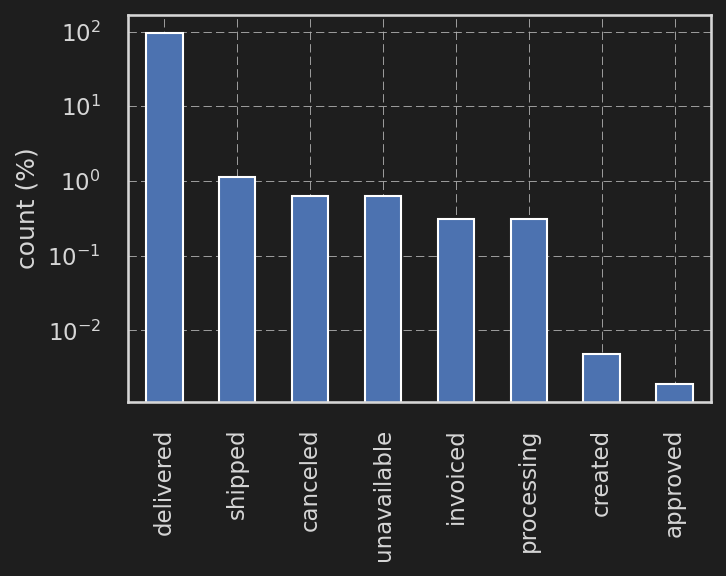

In [54]:
key = 'order_status'
value_counts = 100*(df_merged[key].value_counts(normalize=True))
display(value_counts)

fig, ax = plt.subplots(figsize=(5,4))
value_counts.plot(kind='bar', logy=True, ax=ax)
ax.set_ylabel('count (%)')

fig.tight_layout()
savefig(fig, path_print + 'order_status')

In [14]:
df_merged['order_purchase_timestamp'].dt.year.value_counts()

2018    56238
2017    47891
2016      349
Name: order_purchase_timestamp, dtype: int64

Affichage des données temporelles

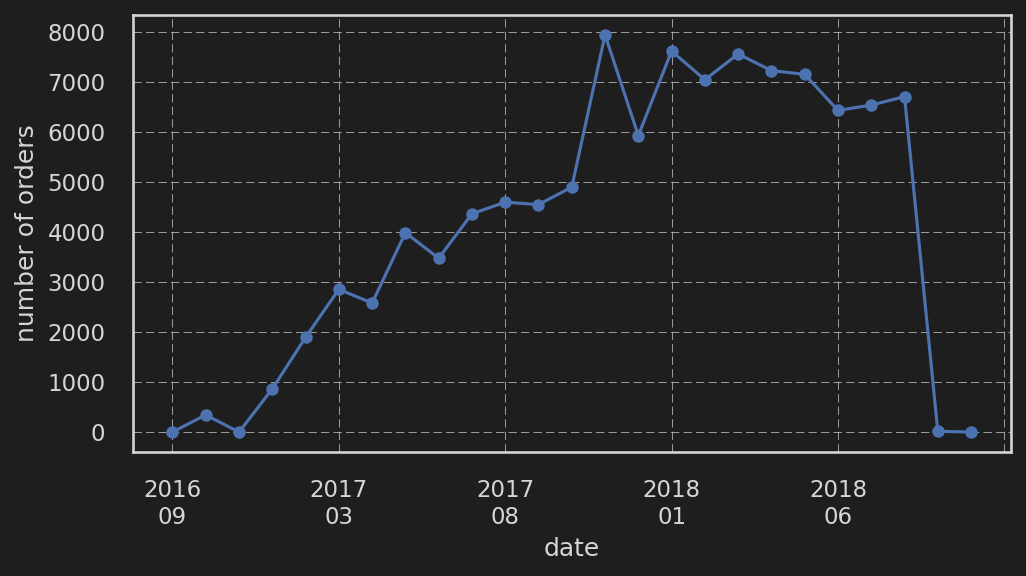

In [55]:
fig, ax = plt.subplots( figsize=(7,4) )
# df_merged['order_purchase_timestamp'].apply(lambda x: x.strftime('%Y\n%m') ).value_counts().sort_index().plot(kind='line', ax=ax, style='-o')
df_merged['order_purchase_timestamp'].dt.strftime('%Y\n%m').value_counts().sort_index().plot(kind='line', ax=ax, style='-o')
ax.set_ylabel('number of orders')
ax.set_xlabel('date')
fig.tight_layout()

savefig(fig, path_print + 'N_orders_vs_time')

In [16]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 104478 entries, 0 to 104477
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       104478 non-null  object        
 1   customer_id                    104478 non-null  object        
 2   order_status                   104478 non-null  object        
 3   order_purchase_timestamp       104478 non-null  datetime64[ns]
 4   order_approved_at              104302 non-null  datetime64[ns]
 5   order_delivered_carrier_date   102580 non-null  datetime64[ns]
 6   order_delivered_customer_date  101324 non-null  datetime64[ns]
 7   order_estimated_delivery_date  104478 non-null  datetime64[ns]
 8   customer_unique_id             104478 non-null  object        
 9   customer_zip_code_prefix       104478 non-null  int64         
 10  customer_city                  104478 non-null  object        
 11  

In [17]:
df_merged['order_purchase_timestamp'].max()

Timestamp('2018-10-17 17:30:18')

Calcul variables RFM (Récence, Fréquence, Montant)

In [56]:
print('customer_id :', df_merged['customer_id'].value_counts().shape)
print('customer_unique_id :', df_merged['customer_unique_id'].value_counts().shape)


groups = df_merged[['customer_unique_id', 'payment_value']].copy()
groups['number_of_days_since_last_order'] = (df_merged['order_purchase_timestamp'].max()
                                             - df_merged['order_purchase_timestamp']
                                            ).dt.days

groups = groups.groupby(by='customer_unique_id')

df_model = groups.agg( {'number_of_days_since_last_order':'max',
                        'customer_unique_id':'count',
                        'payment_value':'sum'
                       } )
df_model.rename(columns={'number_of_days_since_last_order':'Récence',
                         'customer_unique_id':'Fréquence',
                         'payment_value':'Montant'
                        }, inplace=True)

display(df_model.iloc[18:27,:])

customer_id : (99441,)
customer_unique_id : (96096,)


,Récence,Fréquence,Montant
customer_unique_id,,,
000de6019bb59f34c099a907c151d855,425,1,257.44
000e309254ab1fc5ba99dd469d36bdb4,114,2,78.42
000ec5bff359e1c0ad76a81a45cb598f,57,1,27.75
000ed48ceeb6f4bf8ad021a10a3c7b43,150,1,20.75
000fbf0473c10fc1ab6f8d2d286ce20c,83,1,362.38
0010a452c6d13139e50b57f19f52e04e,463,1,325.93
0010fb34b966d44409382af9e8fd5b77,226,1,61.80
001147e649a7b1afd577e873841632dd,412,1,212.16
00115fc7123b5310cf6d3a3aa932699e,633,1,76.11


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,24,19,22,26,29,17,33,23
Fréquence,90290,4569,740,256,82,63,31,13,12,8,7,6,4,3,2,2,2,1,1,1,1,1,1
%,93.958,4.755,0.77,0.266,0.085,0.066,0.032,0.014,0.012,0.008,0.007,0.006,0.004,0.003,0.002,0.002,0.002,0.001,0.001,0.001,0.001,0.001,0.001


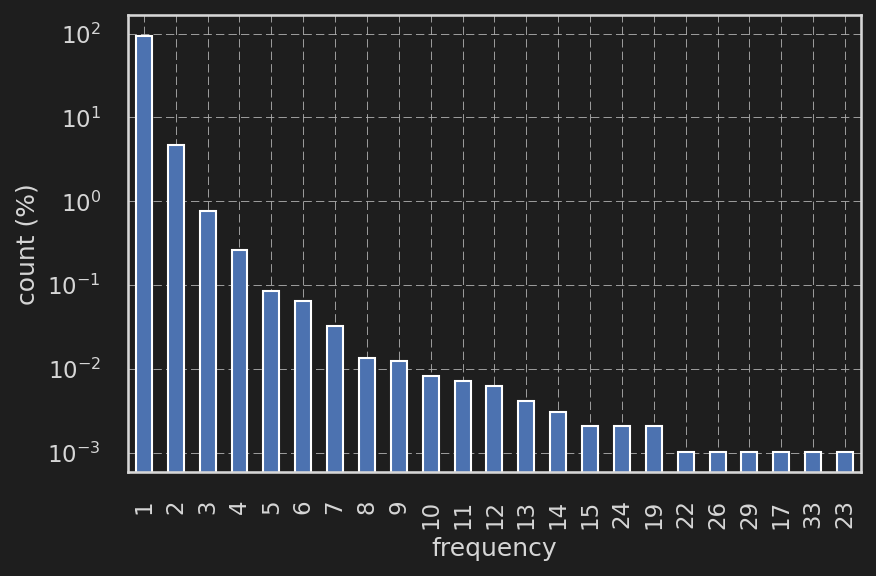

In [58]:
sr_freq = df_model['Fréquence'].value_counts()
df_freq = pd.DataFrame(sr_freq.astype(str)) # str for display
sr_freq *= 100 / sr_freq.sum()
df_freq['%'] = sr_freq.values.round(3)
display(df_freq.T)


fig, ax = plt.subplots(figsize=(6,4))
sr_freq.plot(kind='bar', ax=ax, logy=True)
ax.set_xlabel('frequency')
_ = ax.set_ylabel('count (%)')

fig.tight_layout()
savefig(fig, path_print + 'Frequence')


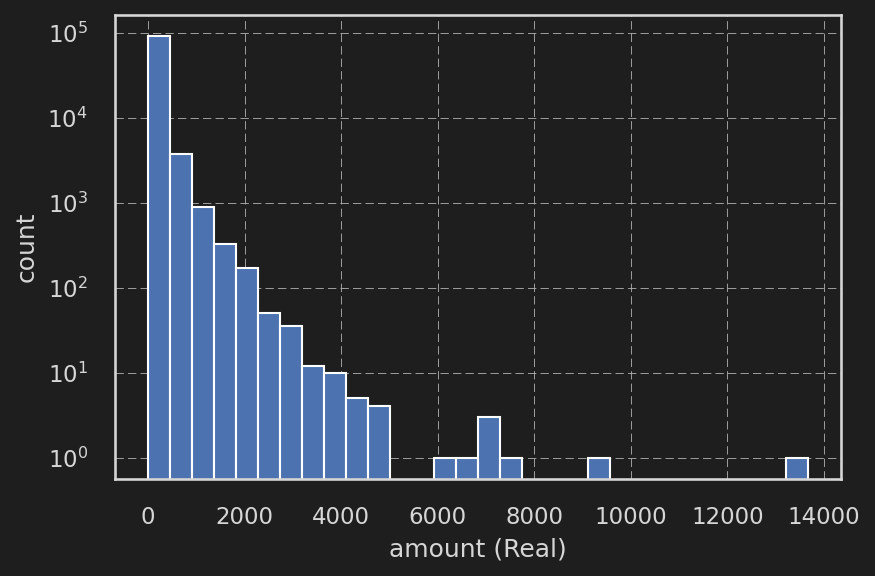

In [60]:
fig, ax = plt.subplots(figsize=(6,4))

df_model.hist(column='Montant', bins=30, ax=ax)
ax.set_yscale('log')
ax.set_title('')
ax.set_xlabel('amount (Real)')
ax.set_ylabel('count')
fig.tight_layout()
savefig(fig, path_print + 'Montant')

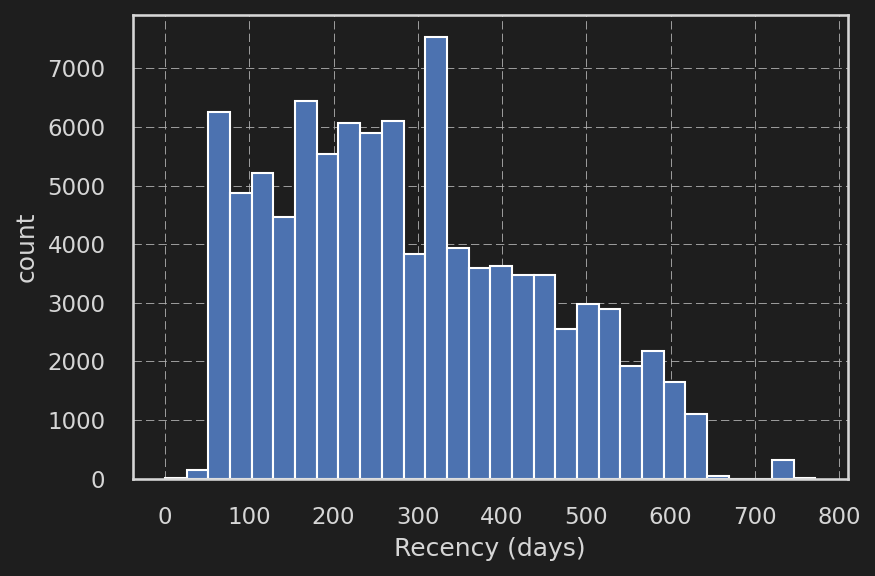

In [65]:
fig, ax = plt.subplots(figsize=(6,4))

df_model.hist(column='Récence', bins=30, ax=ax)
ax.set_title('')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('count')
fig.tight_layout()
savefig(fig, path_print + 'Recence')

Utilisation de quantiles

Pair plot :

La seule corrélation visible est entre les variables "Montant" et "Frequence".

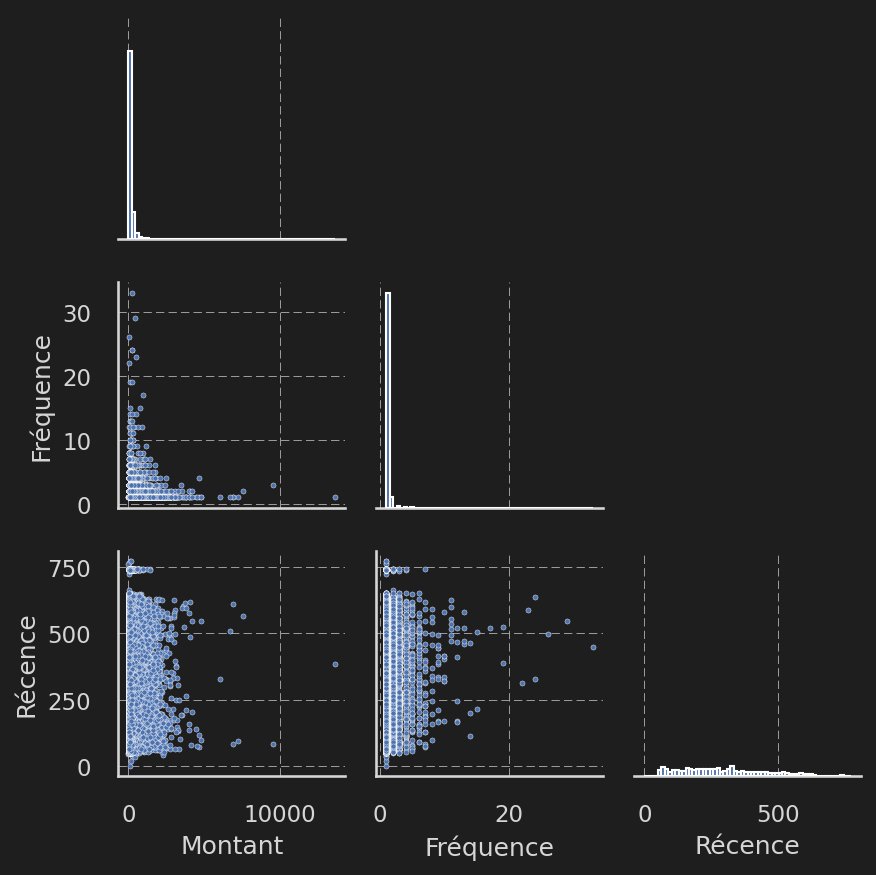

In [66]:
sort_order = ['Montant','Fréquence', 'Récence']

g = sns.PairGrid(df_model, vars=sort_order,corner=True, height=2)
g.map_diag(plt.hist, bins=60)
g.map_lower(sns.scatterplot, s=6)
g.fig.tight_layout()

g.fig.savefig(path_print + 'pair_plot.png')

## 2.2. <a id='toc2_2_'></a>[Analyse par quantiles](#toc0_)

categories Fréquence: Int64Index([1, 2, 3], dtype='int64')
categories Montant: Int64Index([1, 2, 3], dtype='int64')
categories Récence: Int64Index([1, 2, 3], dtype='int64')


,Récence,Fréquence,Montant
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,3,1,2
0000b849f77a49e4a4ce2b2a4ca5be3f,3,1,1
0000f46a3911fa3c0805444483337064,1,1,2
0000f6ccb0745a6a4b88665a16c9f078,1,1,1
0004aac84e0df4da2b147fca70cf8255,2,1,3


<class 'pandas.core.frame.DataFrame'>
Index: 96096 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Récence    96096 non-null  category
 1   Fréquence  96096 non-null  category
 2   Montant    96096 non-null  category
dtypes: category(3)
memory usage: 3.0+ MB


None

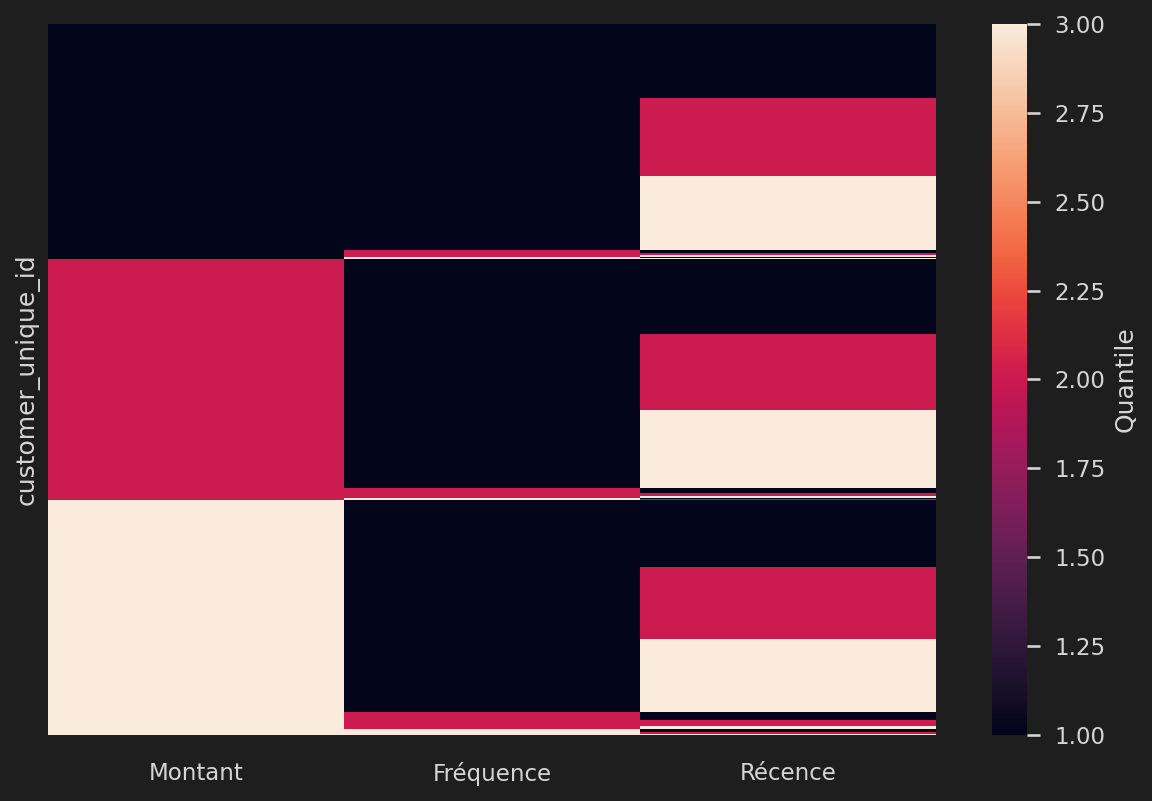

In [69]:
df_quantiles = df_model.copy()

# Frequence
key = 'Fréquence'
# On laisse les valeurs 1 et 2 telles quelles, les autres (> 2) sont en catégorie 3
df_quantiles.loc[ df_quantiles[key]>2, key] = 3
df_quantiles[key] = df_quantiles[key].astype('category')
print(f'categories {key}:', df_quantiles[key].cat.categories)

key = 'Montant'
quantiles = df_quantiles[key].quantile([0.33, 0.67])
categs = np.digitize(df_quantiles[key].values, bins=quantiles)
df_quantiles[key] = 1 + categs
df_quantiles[key] = df_quantiles[key].astype('category')
print(f'categories {key}:', df_quantiles[key].cat.categories)

key = 'Récence'
quantiles = df_quantiles[key].quantile( [0.33, 0.67] )
categs = np.digitize(df_quantiles[key].values, bins=quantiles)
df_quantiles[key] = 3 - categs
df_quantiles[key] = df_quantiles[key].astype('category')
print(f'categories {key}:', df_quantiles[key].cat.categories)


ax = sns.heatmap(df_quantiles[sort_order].astype('float').sort_values( by=sort_order ),
                 cbar_kws={'label': 'Quantile'})
ax.set_yticks([])

fig = ax.get_figure()
fig.tight_layout()
fig.savefig(path_print + 'quantiles.png')

display(df_quantiles.head(5))
display(df_quantiles.info())

Calcul score RFM

In [70]:
df_quantiles['RFM'] = df_quantiles['Récence'].astype(str) + df_quantiles['Fréquence'].astype(str) + df_quantiles['Montant'].astype(str)

df_quantiles.head(5)

,Récence,Fréquence,Montant,RFM
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,3,1,2,312
0000b849f77a49e4a4ce2b2a4ca5be3f,3,1,1,311
0000f46a3911fa3c0805444483337064,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,1,1,1,111
0004aac84e0df4da2b147fca70cf8255,2,1,3,213


Usual categories of custormers using RFM score:

| categorie | RFM | Description |
| :--- | :--- | :---: |
| Best Customers | 333 | Achats récents, fréquents, et dépenses importantes |
| Loyal Customers | 33x | Achats récents et fréquents |
| Almost Lost | 233 | Plus d'achats depuis quelques temps, mais a acheté fréquemment et dépensé beaucoup |
| Lost Customers | 133 | Plus d'achats depuis longtemps, mais a acheté fréquemment et dépensé beaucoup  |
| Big Spenders |  XX3 | Dépenses importantes |
| Lost Cheap Customers | 111 | Achats anciens, peu fréquents et petit montants |


In [71]:
segment_mapping = {
                   r'[3][3][3]': 'Best',
                   r'[3][3][1-2]': 'Loyal',
                   r'[3][1-2][0-9]': 'New', 

                   r'[2][3][0-9]': 'Almost Lost',
                   r'[2][2][0-9]': 'Potentially Loyal',
                    
                   r'[1-2][1][0-9]': 'One Shot',
                   r'[1][2-3][0-9]': 'Lost',
}

df_model['RFM' ] = df_quantiles['RFM']
df_model['Segment'] = df_quantiles['RFM'].replace(segment_mapping, regex=True)

# check all mapped
print('number of entries:', len(df_model))
is_converted = pd.to_numeric(df_model['Segment'], errors='coerce').isna()
print('number of converted:', is_converted.sum())

display(df_model.head(10).style.set_caption('head of the DataFrame'))
df_model.drop(columns='RFM', inplace=True)

number of entries: 96096
number of converted: 96096


,Récence,Fréquence,Montant,RFM,Segment
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.900000,312,New
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.190000,311,New
0000f46a3911fa3c0805444483337064,585,1,86.220000,112,One Shot
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.620000,111,One Shot
0004aac84e0df4da2b147fca70cf8255,336,1,196.890000,213,One Shot
0004bd2a26a76fe21f786e4fbd80607f,194,1,166.980000,313,New
00050ab1314c0e55a6ca13cf7181fecf,180,1,35.380000,311,New
00053a61a98854899e70ed204dd4bafe,231,1,419.180000,213,One Shot
0005e1862207bf6ccc02e4228effd9a0,591,1,150.120000,112,One Shot


In [73]:
groups = df_model.groupby(by='Segment')
df_RFM_segments = groups.agg(['min', 'max', 'mean'])
for key in ['Récence', 'Fréquence', 'Montant']:
    df_RFM_segments[(key, 'mean')] = df_RFM_segments[(key, 'mean')].round(2)
df_RFM_segments['count'] = groups['Récence'].agg('count')
df_RFM_segments['count (%)'] = (df_RFM_segments['count'] * (100/len(df_model))).round(2)

display(df_RFM_segments)

prop_New_One_Shot = df_RFM_segments.loc[['One Shot', 'New'], 'count (%)'].sum()
print('{:.2f}% are "New" or "One Shot"'.format(prop_New_One_Shot))

n_F_sup_1 = (df_model['Fréquence'] > 1).sum()
print(f'{n_F_sup_1/len(df_model):.2%} bought more than once')

Récence              Fréquence           Montant            \
                      min  max    mean       min max  mean     min       max   
Segment                                                                        
Almost Lost           200  345  270.89         3  24  3.82   19.07   2486.01   
Best                   49  199  123.60         3  14  3.85  154.15   9553.02   
Lost                  346  744  476.69         2  33  2.53   16.05   7571.63   
Loyal                  50  198  130.40         3  14  4.14   17.38    151.10   
New                     0  199  125.57         1   2  1.03    0.00   7274.88   
One Shot              200  772  370.13         1   1  1.00    0.00  13664.08   
Potentially Loyal     200  345  273.51         2   2  2.00   16.37   3297.40   

                           count count (%)  
                     mean                   
Segment                                     
Almost Lost        322.40    413      0.43  
Best               552.66     96      0.10  
Lost               266.73   2622      2.73  
Loyal               85.24    125      0.13  
New                168.01  31466     32.74  
One Shot           159.65  59866     62.30  
Potentially Loyal  225.97   1508      1.57

95.04% are "New" or "One Shot"
6.04% bought more than once


## 2.3. <a id='toc2_3_'></a>[Analyse de variables supplémentaires](#toc0_)

### 2.3.1. <a id='toc2_3_1_'></a>[Review score](#toc0_)

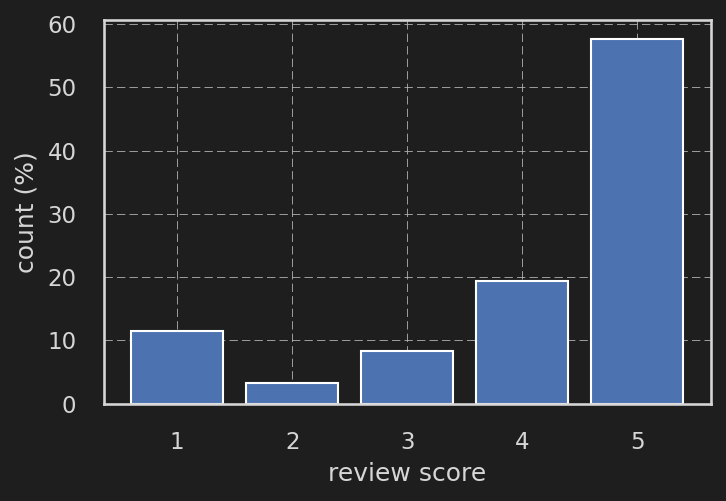

In [74]:
fig, ax = plt.subplots(figsize=(5,3.5))
tmp = 100*df_merged['review_score'].value_counts(normalize=True)
ax.bar(tmp.index.values, tmp)
ax.set_xlabel('review score')
ax.set_ylabel('count (%)')
fig.tight_layout()

fig.tight_layout()
savefig(fig, path_print + 'review_score')

### 2.3.2. <a id='toc2_3_2_'></a>[Retard de livraison](#toc0_)

In [76]:
loc = df_merged['order_status'] == 'delivered'

key = 'delivery_time'
df_merged[key] = np.nan
df_merged.loc[loc, key] = df_merged.loc[loc, 'order_delivered_customer_date'] - df_merged.loc[loc, 'order_purchase_timestamp']

key = 'estimated_delivery_time'
df_merged[key] = np.nan
df_merged.loc[loc, key] = df_merged.loc[loc, 'order_estimated_delivery_date'] - df_merged.loc[loc, 'order_purchase_timestamp']

# DELIVRY DELAY, EXPRESSED IN HOURS
key = 'delivery_delay'
df_merged[key] = np.nan
delay = df_merged.loc[loc, 'delivery_time'] - df_merged.loc[loc, 'estimated_delivery_time']
df_merged.loc[loc, key] = 24*delay.dt.days + delay.dt.seconds/3600

df_merged.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time,estimated_delivery_time,delivery_delay
66208,ff0d3c8b486f123087d9d9da102afaf6,bd33c2c896c5ff73c205660af316b420,delivered,2017-09-02 00:50:36,2017-09-03 00:55:12,2017-09-05 13:34:23,2017-09-08 17:03:56,2017-09-21,5faa665d5980f821e7dfe72d577fe35d,3755,sao paulo,SP,1.0,credit_card,8.0,133.96,bf9cef1e8996ecf8a981caef0e312b23,1.0,NaN,Aguardando a retirada e entrega do produto cor...,2017-09-09 00:00:00,2017-09-13 18:46:26,6 days 16:13:20,18 days 23:09:24,-294.934444
14185,a05d9f0572c423875de7dd4d2c24e34a,35a27dd031233d1d0f5080ef6d09198f,delivered,2018-03-03 18:15:25,2018-03-03 18:35:31,2018-03-06 17:51:57,2018-03-21 22:28:46,2018-03-21,fe337543e79895a128634d2f9d02dcab,3968,sao paulo,SP,1.0,credit_card,5.0,63.07,16e36e253957c7eb5adf1fa9714edba0,5.0,NaN,NaN,2018-03-22 00:00:00,2018-03-23 02:08:42,18 days 04:13:21,17 days 05:44:35,22.479444
47559,804af8e63aed82b9d93e1c39c2ec49a3,c29fdeabf5b90b91bc8d577b68b5c242,delivered,2017-09-10 18:34:03,2017-09-12 04:25:52,2017-09-12 18:14:37,2017-09-13 21:09:36,2017-09-21,63af244c286d898727485f8856edceb1,23059,rio de janeiro,RJ,1.0,boleto,1.0,50.84,9ee945c4d54234be8f594d3665f33b7b,5.0,NaN,Chegou mt rápido bem antes do prazo recomendo,2017-09-14 00:00:00,2017-09-15 00:35:42,3 days 02:35:33,10 days 05:25:57,-170.840000
31498,1726692d7d3bf55b3bf72214ed9e6f7e,693d02fe5397d7acda742a75d955610e,delivered,2017-02-04 13:00:52,2017-02-04 13:15:12,2017-02-06 14:17:36,2017-02-08 14:05:10,2017-03-01,f9a3385a7764e9ff101e0187418fc131,14401,franca,SP,1.0,credit_card,2.0,166.06,6666aab2828ce4e5bdaf5509b6e347a4,4.0,NaN,NaN,2017-02-09 00:00:00,2017-02-10 02:38:29,4 days 01:04:18,24 days 10:59:08,-489.913889
71501,b6fa3751148ad8ba139779f6543951d9,f7a412f8010d1609da2be707d4e9367c,delivered,2017-07-14 21:10:48,2017-07-14 21:25:08,2017-07-18 21:41:24,2017-07-20 19:52:14,2017-08-01,c232da5e4e536a58508df447aa6a5149,25520,sao joao de meriti,RJ,1.0,credit_card,4.0,47.84,52c35a24878f2b51dd910e456fa27c32,3.0,NaN,"o produto é bonito, mas muito frági,l chegou b...",2017-07-21 00:00:00,2017-07-22 00:05:05,5 days 22:41:26,17 days 02:49:12,-268.129444
78858,9e0e712546092840f5d209f6d4864f8e,220d33ea999487ba945f1c187f92ad04,delivered,2017-07-10 16:22:12,2017-07-10 16:30:29,2017-07-11 17:03:53,2017-07-14 19:39:41,2017-08-01,971e2252d557c5f6b2de810f6fcd52eb,14094,ribeirao preto,SP,1.0,credit_card,10.0,223.14,519681733779e62f4cddf12f252190cb,5.0,NaN,NaN,2017-07-15 00:00:00,2017-07-18 14:24:44,4 days 03:17:29,21 days 07:37:48,-412.338611
26908,f495929260b8f76b254652d9729e8c19,ae5885f1bc253502b27227a59692081b,delivered,2018-01-10 13:17:58,2018-01-12 02:33:41,2018-02-01 21:37:17,2018-02-26 16:47:31,2018-02-08,1f65f8bf7307ea4b643dbc85bb1bd613,89255,jaragua do sul,SC,1.0,boleto,1.0,161.37,4a0d0d33b7621448e1516eca8bad52cb,2.0,NaN,NaN,2018-02-16 00:00:00,2018-02-18 19:26:29,47 days 03:29:33,28 days 10:42:02,448.791944
8420,0b01066982af6f2681ea9b0169f0d987,b6468b4d8c27698cc09468fa3efa39d8,delivered,2018-03-19 16:06:01,2018-03-19 16:27:19,2018-03-20 17:32:04,2018-04-13 16:47:01,2018-04-06,40bb6e4754ff5f9199f857e146af0cb5,30520,belo horizonte,MG,1.0,credit_card,3.0,129.59,958072afab08ff7bdeaa28f281ea989c,1.0,NaN,A mercadoria ainda não chegou.,2018-04-08 00:00:00,2018-04-10 15:15:42,25 days 00:41:00,17 days 07:53:59,184.783611
102183,cf101c3abd3c061ca9f78c1bbb1125af,351e40989da90e70487765f6ea15d54b,delivered,2017-07-13 10:42:37,2017-07-14 09:05:12,2017-07-14 19:25:34,2017-07-21 20:42:56,2017-08-04,74adf920dbd3d2e6e9f18acd88b2fd41,11680,ubatuba,SP,2.0,voucher,1.0,8.46,b9bee04e53b712a285795bfcec346c0c,3.0,NaN,"A loja sim ,

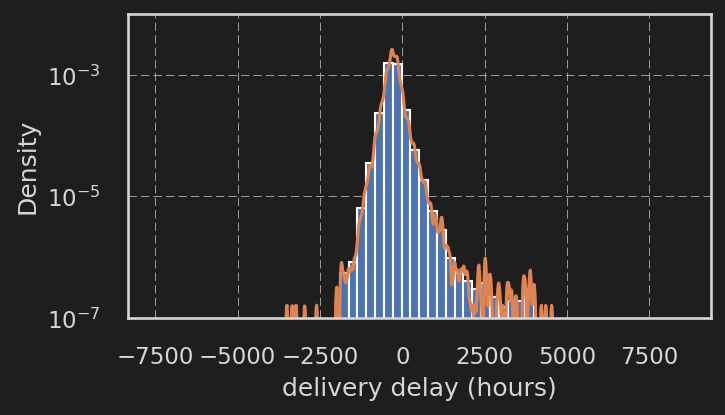

In [79]:
fig, ax = plt.subplots(figsize=(5,3)
a, b, c = ax.hist(df_merged['delivery_delay'], bins=30, density=True)
df_merged['delivery_delay'].plot(kind='density', ax=ax)
ax.set_yscale('log')
ax.set_ylim([1e-7, 1e-2])
ax.set_xlabel('delivery delay (hours)')

fig.tight_layout()
savefig(fig, path_print + 'delivery_delay')

,Récence,Fréquence,Montant,delivery_delay
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,-99.189722
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,-101.955000
0000f46a3911fa3c0805444483337064,585,1,86.22,-33.353611
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,-266.615278
0004aac84e0df4da2b147fca70cf8255,336,1,196.89,-168.851111


Number of NaN in the new variable: 0


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/04_segmenter_clients_ecommerce/.venv2/lib64/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:1259: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(


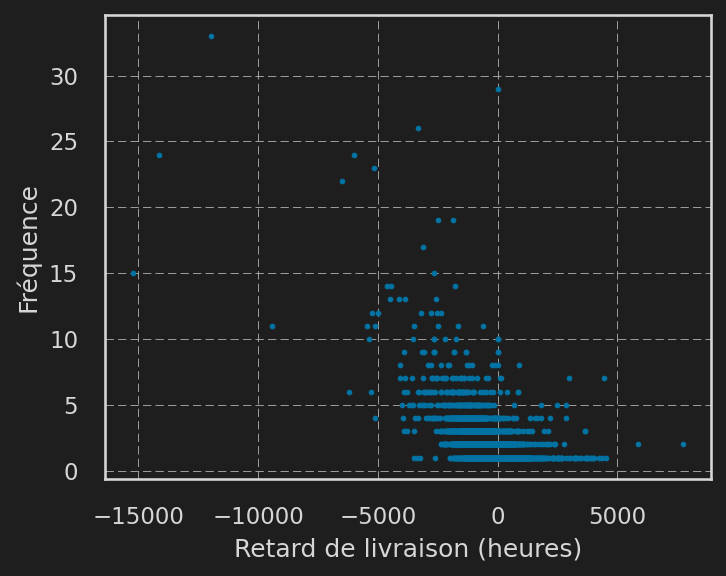

In [84]:
groups = df_merged[['customer_unique_id',
                    'payment_value',
                    'delivery_delay'
                  ]].copy()
groups['number_of_days_since_last_order'] = (df_merged['order_purchase_timestamp'].max() - df_merged['order_purchase_timestamp']).dt.days

groups = groups.groupby(by='customer_unique_id')


df_model = groups.agg({'number_of_days_since_last_order':'max',
                       'customer_unique_id':'count',
                       'payment_value':'sum',
                       'delivery_delay':'sum'
                      })

df_model.rename(columns={'number_of_days_since_last_order':'Récence',
                         'customer_unique_id':'Fréquence',
                         'payment_value':'Montant',
                        }, inplace=True)

features = df_model.columns

display(df_model.head(5))
print('Number of NaN in the new variable:', df_model['delivery_delay'].isna().sum())

fig, ax = plt.subplots(figsize=(5,4))
df_model.plot(kind='scatter', ax=ax, x='delivery_delay', y='Fréquence', s=3)
ax.set_xlabel('Retard de livraison (heures)')

fig.tight_layout()
fig.savefig(path_print + 'delivery_delay_vs_frequency.png')

### 2.3.3. <a id='toc2_3_3_'></a>[Type de paiement](#toc0_)

count (%):


credit_card    73.889947
boleto         19.056826
voucher         5.580176
debit_card      1.470180
not_defined     0.002871
Name: payment_type, dtype: float64

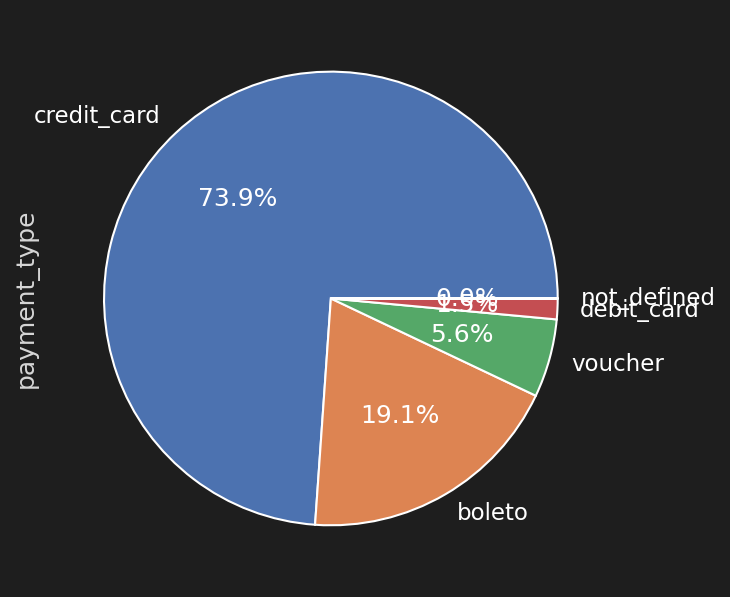

In [85]:
value_count = df_merged['payment_type'].value_counts()
ax = value_count.plot(kind='pie', autopct='%1.1f%%', figsize=(5,5))

fig = ax.get_figure()
fig.tight_layout()
savefig(fig, path_print + 'payment_type')

print('count (%):')
display(value_count * (100 / value_count.sum()))